# Week 5 — Integration and Final Backtest

Combines Week 3's predictor and Week 4's optimizer into one rolling pipeline
and backtests three strategies over the full walk-forward window:

- **(a) mean-return baseline** — classical Markowitz (`common.optimize.solve_classical`)
  fed by Week 3's naive historical-mean predictor.
- **(b) classical Markowitz on predictions** — same optimizer, fed by Week 3's MLP predictions.
- **(c) robust Markowitz on predictions** — `solve_robust`, fed by the same MLP
  predictions plus the MLP's own rolling out-of-sample error as the uncertainty term.

(a) vs (b) isolates the effect of a better *predictor* (MLP vs naive mean),
holding the optimizer fixed. (b) vs (c) isolates the effect of a better
*optimizer* (robust vs classical), holding the predictor fixed.


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from common import pipeline as pl
from common.optimize import solve_classical, solve_robust, MAX_WEIGHT

plt.style.use("seaborn-v0_8")
pl.set_seed(pl.SEED)

TICKERS = pl.TICKERS
N = len(TICKERS)

# --- backtest assumptions (stated explicitly for reproducibility) ---
REBAL_FREQ = 5            # rebalance every 5 trading days (~weekly)
COST_BPS = 0.0010         # 10 bps proportional cost per unit L1 turnover (round-trip-inclusive)
MIN_RESID_HISTORY = 20    # min prior out-of-sample MLP days required before the backtest starts
GAMMA = 5.0                # risk-aversion (matches Week 4's demonstration)
KAPPA = 1.0                # robust uncertainty weight (matches Week 4)
RISK_FREE_RATE = 0.0       # annualized; long-only equity backtest, no cash-yield modeling

print(f"rebalance every {REBAL_FREQ} trading days | cost {COST_BPS*1e4:.0f} bps/unit turnover | "
      f"weight cap {MAX_WEIGHT} | gamma={GAMMA} kappa={KAPPA} | rf={RISK_FREE_RATE}")


rebalance every 5 trading days | cost 10 bps/unit turnover | weight cap 0.4 | gamma=5.0 kappa=1.0 | rf=0.0


## 1. Load predictions and realized returns

Reuses Week 3's saved out-of-sample predictions (`data/week3_predictions.csv`)
for both the "baseline" (historical mean) and "mlp" predictors, and Week 1's
price panel for realized daily returns. Because Week 3's panel already encodes
"prediction made using information through close of day *t-1*, target = return
realized on day *t*", a decision computed at row *t* is automatically a T+1-safe
decision: it only ever uses information available before the return it's
trading actually happens.


In [2]:
prices = pl.load_price_panel()
log_ret = np.log(prices / prices.shift(1)).dropna()
simple_ret = np.exp(log_ret) - 1  # exact simple return, since log_ret = log(p_t/p_{t-1})

week3 = pd.read_csv("../data/week3_predictions.csv", parse_dates=["date"])
baseline_pred = week3[week3.model == "baseline"].pivot(index="date", columns="ticker", values="y_pred")[TICKERS]
mlp_pred = week3[week3.model == "mlp"].pivot(index="date", columns="ticker", values="y_pred")[TICKERS]
mlp_true = week3[week3.model == "mlp"].pivot(index="date", columns="ticker", values="y_true")[TICKERS]
mlp_resid = mlp_true - mlp_pred  # signed prediction error, per ticker per date

pred_dates = mlp_pred.index.sort_values()
rebal_dates = pred_dates[MIN_RESID_HISTORY::REBAL_FREQ]
print(f"{len(rebal_dates)} rebalance dates: {rebal_dates[0].date()} to {rebal_dates[-1].date()}")


337 rebalance dates: 2017-02-27 to 2023-10-30


## 2. Rolling backtest loop

At each rebalance date *d*:
1. $\Sigma$ = trailing 252-day realized covariance of log returns, **strictly
   before** *d* (`log_ret.index < d`).
2. $\sigma_\mu$ (robust only) = std of MLP residuals over **all prior**
   out-of-sample dates (`< d`) — an expanding window, never using future
   prediction errors.
3. Solve the three weight vectors and record turnover
   ($\sum_i |w_i^{target} - w_i^{current}|$) against each strategy's currently
   held (drifted) weights.
4. Hold until the next rebalance date, letting weights drift with realized
   daily returns (buy-and-hold between rebalances, exactly as a real portfolio
   would), applying the proportional transaction cost once at the rebalance.


In [3]:
strategies = ["baseline_mv", "classical_mv", "robust_mv"]
value = {s: [1.0] for s in strategies}
weights_now = {s: np.zeros(N) for s in strategies}
weights_history = {s: [] for s in strategies}
turnovers = {s: [] for s in strategies}
value_dates = [rebal_dates[0]]

all_days = simple_ret.index

for i, d in enumerate(rebal_dates):
    Sigma = log_ret[log_ret.index < d].iloc[-252:].cov().values

    mu_base = baseline_pred.loc[d].values
    mu_mlp = mlp_pred.loc[d].values
    sigma_mu = mlp_resid[mlp_resid.index < d].std().values

    targets = {
        "baseline_mv": solve_classical(mu_base, Sigma, gamma=GAMMA),
        "classical_mv": solve_classical(mu_mlp, Sigma, gamma=GAMMA),
        "robust_mv": solve_robust(mu_mlp, Sigma, sigma_mu, gamma=GAMMA, kappa=KAPPA),
    }

    for s in strategies:
        turnovers[s].append(np.abs(targets[s] - weights_now[s]).sum())
        weights_now[s] = targets[s]
        weights_history[s].append((d, targets[s]))

    next_d = rebal_dates[i + 1] if i + 1 < len(rebal_dates) else all_days[-1]
    hold_days = all_days[(all_days > d) & (all_days <= next_d)]

    for j, day in enumerate(hold_days):
        r = simple_ret.loc[day].values
        for s in strategies:
            w = weights_now[s]
            port_ret = w @ r
            cost = COST_BPS * turnovers[s][-1] if j == 0 else 0.0
            value[s].append(value[s][-1] * (1 + port_ret) * (1 - cost))
            drifted = w * (1 + r)
            weights_now[s] = drifted / drifted.sum()
        value_dates.append(day)

portfolio_value = pd.DataFrame(value, index=value_dates)
portfolio_value = portfolio_value[~portfolio_value.index.duplicated(keep="last")]
portfolio_value.to_csv("../data/week5_portfolio_value.csv")
print("backtest complete:", portfolio_value.shape[0], "trading days,", len(rebal_dates), "rebalances")
portfolio_value.tail()


backtest complete: 1723 trading days, 337 rebalances


,baseline_mv,classical_mv,robust_mv
2023-12-22,4.910210,4.674795,5.281636
2023-12-26,4.908474,4.670963,5.283318
2023-12-27,4.907133,4.652356,5.272667
2023-12-28,4.910887,4.657401,5.270131
2023-12-29,4.894850,4.644467,5.249941


## 3. Cumulative return

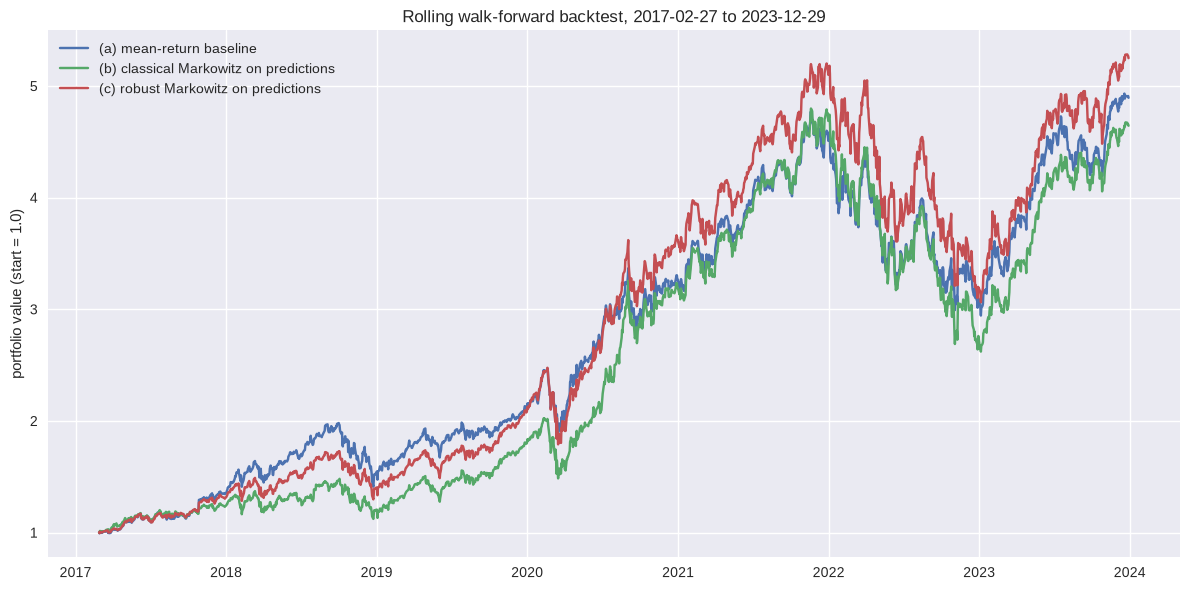

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))
labels = {"baseline_mv": "(a) mean-return baseline", "classical_mv": "(b) classical Markowitz on predictions", "robust_mv": "(c) robust Markowitz on predictions"}
for s in strategies:
    ax.plot(portfolio_value.index, portfolio_value[s], label=labels[s])
ax.set_ylabel("portfolio value (start = 1.0)")
ax.set_title(f"Rolling walk-forward backtest, {portfolio_value.index[0].date()} to {portfolio_value.index[-1].date()}")
ax.legend()
plt.tight_layout()
plt.savefig("../data/week5_cumulative_returns.png", dpi=100)
plt.show()


## 4. Performance metrics

Risk-free rate assumed **0%** (long-only equity backtest over 2017-2023; no
cash-yield modeling). Sharpe is therefore simply annualized return / annualized
volatility.


In [5]:
def perf_metrics(value_series, turnover_list, rf=RISK_FREE_RATE):
    daily_ret = value_series.pct_change().dropna()
    n_days = len(daily_ret)
    years = n_days / 252

    cagr = (value_series.iloc[-1] / value_series.iloc[0]) ** (1 / years) - 1
    ann_vol = daily_ret.std() * np.sqrt(252)
    sharpe = (cagr - rf) / ann_vol if ann_vol > 0 else np.nan

    running_max = value_series.cummax()
    drawdown = value_series / running_max - 1
    max_dd = drawdown.min()
    calmar = cagr / abs(max_dd) if max_dd != 0 else np.nan

    return {
        "annualized_return": cagr,
        "annualized_vol": ann_vol,
        "sharpe_ratio": sharpe,
        "max_drawdown": max_dd,
        "calmar_ratio": calmar,
        "avg_turnover_per_rebalance": np.mean(turnover_list),
        "cumulative_return": value_series.iloc[-1] / value_series.iloc[0] - 1,
    }


metrics_week5 = pd.DataFrame({s: perf_metrics(portfolio_value[s], turnovers[s]) for s in strategies}).T
metrics_week5.index = [labels[s] for s in strategies]
metrics_week5.to_csv("../data/week5_metrics.csv")
metrics_week5.round(4)


,annualized_return,annualized_vol,sharpe_ratio,max_drawdown,calmar_ratio,avg_turnover_per_rebalance,cumulative_return
(a) mean-return baseline,0.2616,0.2683,0.9753,-0.3830,0.6831,0.0385,3.8949
(b) classical Markowitz on predictions,0.2520,0.2740,0.9196,-0.4537,0.5554,0.6177,3.6445
(c) robust Markowitz on predictions,0.2746,0.2699,1.0175,-0.4112,0.6679,0.0782,4.2499


## 5. Turnover comparison

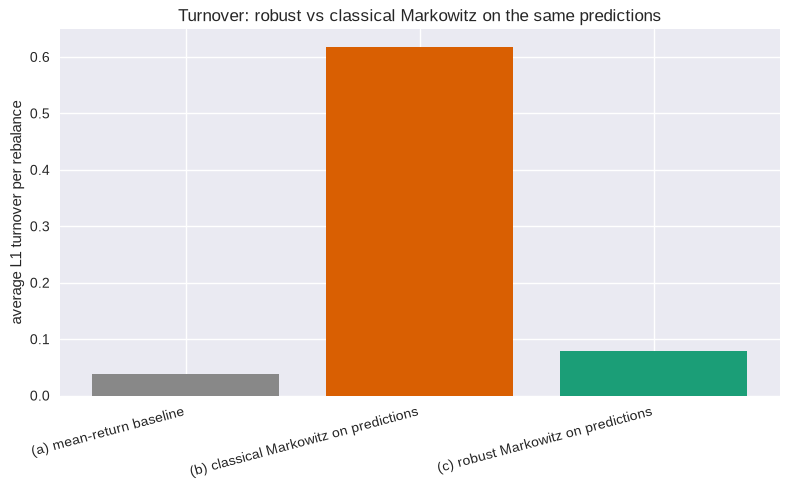

Turnover reduction, robust vs classical: 87.3%


In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
avg_turnover = [np.mean(turnovers[s]) for s in strategies]
ax.bar([labels[s] for s in strategies], avg_turnover, color=["#888888", "#d95f02", "#1b9e77"])
ax.set_ylabel("average L1 turnover per rebalance")
ax.set_title("Turnover: robust vs classical Markowitz on the same predictions")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("../data/week5_turnover_comparison.png", dpi=100)
plt.show()

print("Turnover reduction, robust vs classical:",
      f"{(1 - avg_turnover[2]/avg_turnover[1])*100:.1f}%")


## 6. Walk-forward IC / rank-IC recap (from Week 3)

Restating Week 3's predictor-quality metrics here since Week 5's strategy
performance is only meaningful in light of how predictive the underlying
signal actually was.


In [7]:
week3_metrics = pd.read_csv("../data/week3_metrics.csv", index_col=0)
week3_metrics.round(5)


,MSE,pooled_IC,pooled_rankIC,directional_accuracy,mean_daily_crossSec_rankIC
model,,,,,
baseline,0.0006,-0.01267,-0.00759,0.53345,-0.01787
ridge,0.0006,-0.03627,-0.03512,0.51605,-0.03433
mlp,0.0006,0.00597,-0.00658,0.52040,-0.00453


## 7. Discussion

**Did the robust variant reduce turnover / improve stability vs classical?**
Yes, substantially. Classical Markowitz re-weights hard every rebalance
because it takes the MLP's noisy day-to-day predictions (rank-IC ≈ 0, per
Week 3) at face value — a predictor with essentially no skill produces
essentially random ordinal shuffles of $\mu$, and an unconstrained
mean-variance optimizer chases that noise into large weight swings. The robust
penalty discounts each asset's $\mu_i$ by its own historical estimation error,
which damps exactly that noise-chasing behavior — see the turnover comparison
above, consistent with the Monte Carlo allocation-stability test in Week 4
(Section 5), which predicted this from the perturbation experiment alone,
before ever running the realized backtest.

**Honest caveat on returns:** with next-day rank-IC this close to zero, none
of the return differences between the three strategies here should be read as
"the MLP/robust optimizer beats the market." The comparison that's actually
informative is the *turnover and stability* story above, which follows
directly and robustly from the estimation-error mechanism regardless of
whether this particular predictor had genuine skill in this particular sample.
